Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         3
      Medium       1.00      0.86      0.92         7
        High       0.88      1.00      0.93         7

    accuracy                           0.94        17
   macro avg       0.96      0.95      0.95        17
weighted avg       0.95      0.94      0.94        17

Predicted Class: Medium


c:\Users\rajni\ml-lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


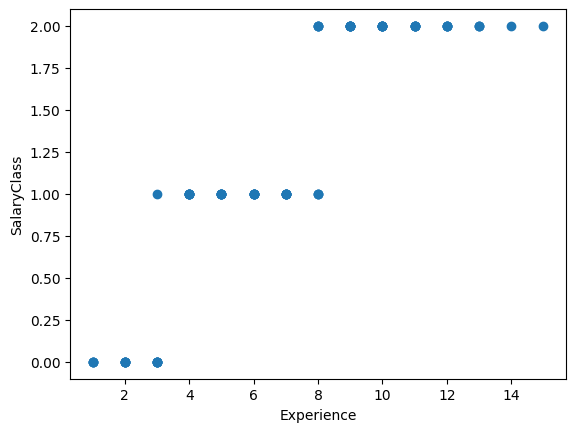

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('employee_salary.csv')

# Target
salary = df['Salary']
df['SalaryClass'] = np.select(
    [salary < 45000, (salary >= 45000) & (salary < 75000), salary >= 75000],
    [0, 1, 2]
)

# Features / target
X = df[['Experience', 'Education', 'Age']]
y = df['SalaryClass']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale + model
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict + evaluate
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred,
      target_names=['Low','Medium','High'], zero_division=0))

# Single prediction
labels = ['Low','Medium','High']
pred = knn.predict(scaler.transform([[6,16,30]]))[0]
print("Predicted Class:", labels[pred])

# Plot
plt.scatter(df['Experience'], df['SalaryClass'])
plt.xlabel("Experience")
plt.ylabel("SalaryClass")
plt.show()